# Modul K-Means Clustering

Rizki Maulana - 1237050088

Dataset yang digunakan adalah data GPS Trajectories dari aplikasi Android **Go!Track**.
Langkah pertama adalah melakukan import library yang dibutuhkan.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

## Pengumpulan dan Persiapan Data

Melakukan load data sehingga data tersebut diubah formatnya ke dalam data frame.

In [2]:
baca = pd.read_csv("go_track_tracks.csv")
baca.head()

,id,id_android,speed,time,distance,rating,rating_bus,rating_weather,car_or_bus,linha
0,1,0,19.210586,0.138049,2.652,3,0,0,1,NaN
1,2,0,30.848229,0.171485,5.290,3,0,0,1,NaN
2,3,1,13.560101,0.067699,0.918,3,0,0,2,NaN
3,4,1,19.766679,0.389544,7.700,3,0,0,2,NaN
4,8,0,25.807401,0.154801,3.995,2,0,0,1,NaN


Melihat informasi tentang dataset.

In [3]:
baca.info()

<class 'pandas.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              163 non-null    int64  
 1   id_android      163 non-null    int64  
 2   speed           163 non-null    float64
 3   time            163 non-null    float64
 4   distance        163 non-null    float64
 5   rating          163 non-null    int64  
 6   rating_bus      163 non-null    int64  
 7   rating_weather  163 non-null    int64  
 8   car_or_bus      163 non-null    int64  
 9   linha           80 non-null     str    
dtypes: float64(3), int64(6), str(1)
memory usage: 14.2 KB


Kolom `linha` dikurangi (di-drop) karena tidak dipergunakan dalam penentuan pada clustering.

In [4]:
baca = baca.drop(["linha"], axis=1)
baca.head()

,id,id_android,speed,time,distance,rating,rating_bus,rating_weather,car_or_bus
0,1,0,19.210586,0.138049,2.652,3,0,0,1
1,2,0,30.848229,0.171485,5.290,3,0,0,1
2,3,1,13.560101,0.067699,0.918,3,0,0,2
3,4,1,19.766679,0.389544,7.700,3,0,0,2
4,8,0,25.807401,0.154801,3.995,2,0,0,1


Menentukan variabel yang akan diklusterkan.
*(Berdasarkan modul, kita menggunakan iloc[:, 1:3] yang mengekstrak kolom `id_android` dan `speed`)*

In [5]:
# Menentukan variabel yang akan di klusterkan
baca_x = baca.iloc[:, 1:3]
baca_x.head()

,id_android,speed
0,0,19.210586
1,0,30.848229
2,1,13.560101
3,1,19.766679
4,0,25.807401


Visualisasi persebaran data awal (berdasarkan modul memvisualkan `distance` vs `speed`).

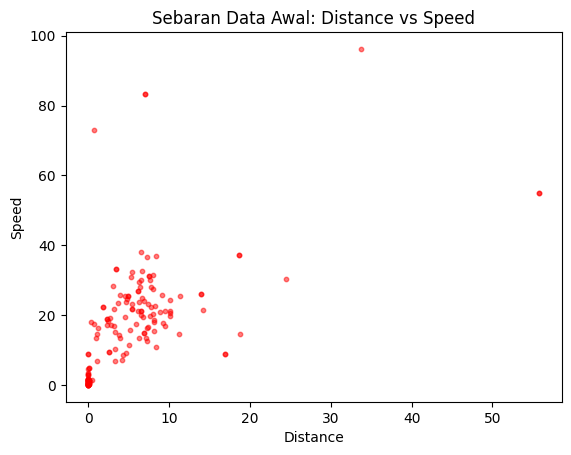

In [6]:
# Memvisualkan persebaran data
plt.scatter(baca.distance, baca.speed, s=10, c="red", marker="o", alpha=0.5)
plt.xlabel("Distance")
plt.ylabel("Speed")
plt.title("Sebaran Data Awal: Distance vs Speed")
plt.show()

Mengubah variabel data menjadi array untuk proses klustering.

In [7]:
x_array = np.array(baca_x)
print(x_array)

[[0.00000000e+00 1.92105856e+01]
 [0.00000000e+00 3.08482291e+01]
 [1.00000000e+00 1.35601009e+01]
 [1.00000000e+00 1.97666790e+01]
 [0.00000000e+00 2.58074009e+01]
 [2.00000000e+00 1.34691332e+00]
 [3.00000000e+00 3.68507874e+01]
 [1.00000000e+00 1.74051313e+01]
 [1.00000000e+00 1.53954361e+01]
 [1.00000000e+00 8.90272944e+00]
 [3.00000000e+00 1.50413480e+01]
 [3.00000000e+00 1.44400981e+01]
 [1.00000000e+00 1.63567325e+01]
 [1.00000000e+00 1.75427999e+01]
 [4.00000000e+00 9.45181557e+00]
 [4.00000000e+00 9.45181557e+00]
 [4.00000000e+00 1.62635039e+01]
 [4.00000000e+00 2.12235944e+01]
 [4.00000000e+00 1.94236545e+01]
 [4.00000000e+00 2.07996291e+01]
 [4.00000000e+00 8.72437242e+00]
 [4.00000000e+00 8.72437242e+00]
 [3.00000000e+00 8.68613764e+00]
 [3.00000000e+00 5.49959473e+01]
 [3.00000000e+00 5.49959473e+01]
 [1.00000000e+00 1.26110448e+01]
 [3.00000000e+00 1.45342872e+01]
 [3.00000000e+00 1.02882267e+01]
 [3.00000000e+00 1.83281891e+01]
 [1.00000000e+00 1.71776350e+01]
 [1.000000

Melakukan normalisasi data menggunakan `MinMaxScaler`.

In [8]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x_array)
x_scaled

array([[0.00000000e+00, 1.99600362e-01],
       [0.00000000e+00, 3.20578504e-01],
       [3.70370370e-02, 1.40861225e-01],
       [3.70370370e-02, 2.05381184e-01],
       [0.00000000e+00, 2.68176999e-01],
       [7.40740741e-02, 1.39000630e-02],
       [1.11111111e-01, 3.82977592e-01],
       [3.70370370e-02, 1.80831914e-01],
       [3.70370370e-02, 1.59940297e-01],
       [3.70370370e-02, 9.24459124e-02],
       [1.11111111e-01, 1.56259404e-01],
       [1.11111111e-01, 1.50009162e-01],
       [3.70370370e-02, 1.69933373e-01],
       [3.70370370e-02, 1.82263037e-01],
       [1.48148148e-01, 9.81538910e-02],
       [1.48148148e-01, 9.81538910e-02],
       [1.48148148e-01, 1.68964223e-01],
       [1.48148148e-01, 2.20526426e-01],
       [1.48148148e-01, 2.01815302e-01],
       [1.48148148e-01, 2.16119130e-01],
       [1.48148148e-01, 9.05918170e-02],
       [1.48148148e-01, 9.05918170e-02],
       [1.11111111e-01, 9.01943506e-02],
       [1.11111111e-01, 5.71604072e-01],
       [1.111111

## Membuat Model Klasifikasi / Clustering

Membuat model KMeans dengan 3 kluster.

In [9]:
# Membuat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

# Training model
# Pada modul menggunakan kmeans.fit(baca), namun lebih tepat jika ditraining pada data yang diekstrak
kmeans.fit(x_scaled)

# Menampilkan label cluster
print(kmeans.labels_)

# Menambahkan hasil cluster ke dataframe
baca["kluster"] = kmeans.labels_

# Menampilkan data
baca.head()

[0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0
 0 2 0 0 2 2 2 0 2 2 2 0 0 0 0 0 0 0 0 0 2 2 2 0 0 2 2 2 2 2 2 2 2 0 0 0 0
 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2
 2 0 0 0 0 0 0 0 0 2 0 2 1 0 2 2 0 0 2 2 1 1 1 2 0 1 1 1 1 1 0 2 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


,id,id_android,speed,time,distance,rating,rating_bus,rating_weather,car_or_bus,kluster
0,1,0,19.210586,0.138049,2.652,3,0,0,1,0
1,2,0,30.848229,0.171485,5.290,3,0,0,1,0
2,3,1,13.560101,0.067699,0.918,3,0,0,2,0
3,4,1,19.766679,0.389544,7.700,3,0,0,2,0
4,8,0,25.807401,0.154801,3.995,2,0,0,1,0


## Membuat Report Hasil Klasifikasi

*Catatan: Modul menampilkan kode untuk metrik klasifikasi (Accuracy, Precision, Recall, F1-Score). Namun, karena K-Means adalah metode Unsupervised Learning dan kita tidak memiliki label asli, metrik klasifikasi tidak bisa digunakan secara langsung tanpa adanya label kebenaran. Sebagai gantinya, kita memvisualisasikan hasil kluster.*

Visualisasi dari kluster beserta dengan plot data centroid.

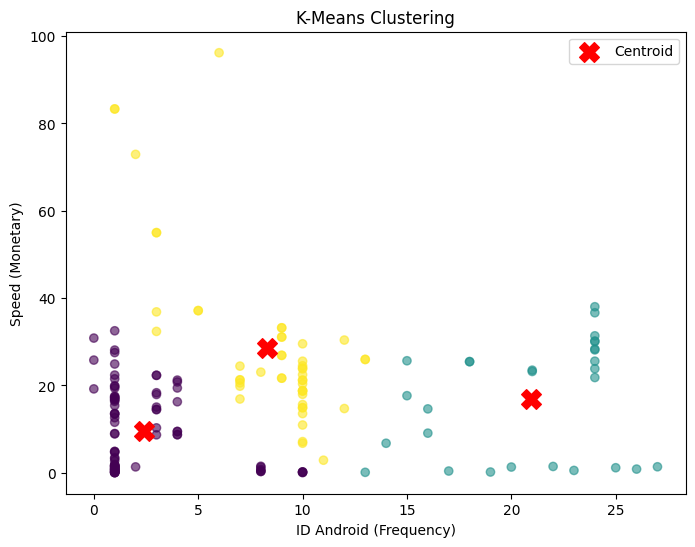

In [10]:
# Plot hasil clustering
plt.figure(figsize=(8,6))

plt.scatter(
    baca['id_android'],
    baca['speed'],
    c=baca['kluster'],
    cmap='viridis',
    alpha=0.6
)

# Titik centroid (perlu dikembalikan ke skala awal agar sesuai dengan plot)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:, 0],   # id_android (Frequency)
    centroids[:, 1],   # speed (Monetary)
    s=200,
    c='red',
    marker='X',
    label='Centroid'
)

plt.xlabel('ID Android (Frequency)')
plt.ylabel('Speed (Monetary)')
plt.title('K-Means Clustering')
plt.legend()

plt.show()